# Fuel Use vs Speed: Polynomial Linearization

We model fuel use against speed with a quadratic, fitted with ordinary linear regression:

$$\text{fuel\_use} = w_2 \cdot \text{speed}^2 + w_1 \cdot \text{speed} + b$$

The curve bends, but the model is still linear in the weights. We add a $\text{speed}^2$ column
and fit it with the same least squares method as a straight line.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

from data_loader import DataLoader

## Part 1: Data setup (Nnamdi)

### Source

**Vehicle Energy Dataset (VED)**, https://github.com/gsoh/VED
G. Oh, D. J. LeBlanc, H. Peng, "Vehicle Energy Dataset (VED), A Large-scale Dataset for Vehicle
Energy Consumption Research", *IEEE Transactions on Intelligent Transportation Systems*, 2020.

VED records real-world driving from 383 cars in Ann Arbor, Michigan (Nov 2017 to Nov 2018),
logged through each car's OBD-II port. We use **vehicle 531**, a gasoline car with a 1.5 L
4-cylinder engine, which has the most driving data of any gasoline car in VED: 478 trips.
`src/extract_ved.py` pulls this vehicle's records out of the raw weekly VED files.

In [2]:
df = DataLoader().load()

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows: 381,876
Columns: 6


,DayNum,VehId,Trip,Timestamp(ms),Vehicle Speed[km/h],MAF[g/sec]
0,2.519458,531,597,0,35.0,12.24
1,2.519458,531,597,1100,36.0,12.46
2,2.519458,531,597,2100,38.0,12.46
3,2.519458,531,597,3100,38.0,3.36
4,2.519458,531,597,4200,37.0,3.36


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 381876 entries, 0 to 381875
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   DayNum               381876 non-null  float64
 1   VehId                381876 non-null  int64  
 2   Trip                 381876 non-null  int64  
 3   Timestamp(ms)        381876 non-null  int64  
 4   Vehicle Speed[km/h]  381876 non-null  float64
 5   MAF[g/sec]           381876 non-null  float64
dtypes: float64(3), int64(3)
memory usage: 17.5 MB


### Check for missing values and duplicates

In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate (Trip, Timestamp) readings:", df.duplicated(["Trip", "Timestamp(ms)"]).sum())

Missing values per column:
DayNum                 0
VehId                  0
Trip                   0
Timestamp(ms)          0
Vehicle Speed[km/h]    0
MAF[g/sec]             0
dtype: int64

Duplicate rows: 0
Duplicate (Trip, Timestamp) readings: 0


In [5]:
df.describe()

,DayNum,VehId,Trip,Timestamp(ms),Vehicle Speed[km/h],MAF[g/sec]
count,381876.000000,381876.0,381876.000000,3.818760e+05,381876.000000,381876.000000
mean,205.875554,531.0,1894.778114,3.113420e+05,34.089508,8.198270
std,102.562827,0.0,701.446099,2.342659e+05,21.720422,7.622216
min,2.519458,531.0,597.000000,0.000000e+00,0.000000,1.590000
25%,120.495450,531.0,1287.000000,1.211000e+05,17.000000,2.740000
50%,210.803116,531.0,1900.000000,2.653000e+05,36.000000,3.790000
75%,294.653705,531.0,2505.000000,4.569000e+05,51.000000,12.389999
max,375.501195,531.0,3100.000000,1.398200e+06,96.000000,49.709999


No values are missing and there are no duplicate readings. Air flow (MAF) is always positive,
and speeds run from 0 to 96 km/h, so no readings are physically impossible.

### Step 1: Derive fuel rate from air flow

VED does not log `Fuel Rate[L/hr]` for this car. It logs **mass air flow** (MAF), the grams of
air entering the engine per second. A gasoline engine burns fuel at a fixed air-to-fuel mass
ratio of about **14.7 : 1**, and gasoline weighs about **745 g per litre**, so:

$$\text{Fuel Rate [L/hr]} = \frac{\text{MAF [g/s]} \times 3600}{14.7 \times 745}$$

In [6]:
AIR_FUEL_RATIO = 14.7        # grams of air per gram of gasoline
GASOLINE_DENSITY = 745       # grams per litre

analysis_df = df[["Trip", "Timestamp(ms)", "Vehicle Speed[km/h]", "MAF[g/sec]"]].copy()
analysis_df["Fuel Rate[L/hr]"] = (
    analysis_df["MAF[g/sec]"] * 3600 / (AIR_FUEL_RATIO * GASOLINE_DENSITY)
)
analysis_df[["Vehicle Speed[km/h]", "MAF[g/sec]", "Fuel Rate[L/hr]"]].describe()

,Vehicle Speed[km/h],MAF[g/sec],Fuel Rate[L/hr]
count,381876.000000,381876.000000,381876.000000
mean,34.089508,8.198270,2.694952
std,21.720422,7.622216,2.505591
min,0.000000,1.590000,0.522668
25%,17.000000,2.740000,0.900699
50%,36.000000,3.790000,1.245857
75%,51.000000,12.389999,4.072867
max,96.000000,49.709999,16.340775


### Step 2: Remove idling

Readings at 0 km/h are real (the engine still burns fuel while idling), but they describe a
different situation. This experiment studies fuel use as a function of **travelling** speed, and
fuel per distance is undefined when no distance is covered, so we remove them.

In [7]:
rows_loaded = len(analysis_df)
idle = analysis_df["Vehicle Speed[km/h]"] == 0
print(f"Idling readings (speed = 0): {idle.sum():,}")

analysis_df = analysis_df[~idle].copy()
print(f"Rows remaining: {len(analysis_df):,}")

Idling readings (speed = 0): 44,092
Rows remaining: 337,784


### Step 3: Convert to fuel use per distance

The assignment is about **fuel use**, the fuel needed to cover a distance. Dividing the fuel rate
(L/hr) by speed (km/h) gives litres per km, which we scale to L/100 km:

$$\text{Fuel Use [L/100km]} = \frac{\text{Fuel Rate [L/hr]}}{\text{Speed [km/h]}} \times 100$$

In [8]:
analysis_df["Fuel Use[L/100km]"] = (
    analysis_df["Fuel Rate[L/hr]"] / analysis_df["Vehicle Speed[km/h]"] * 100
)
analysis_df["Fuel Use[L/100km]"].describe()

count    337784.000000
mean         11.859080
std          18.738151
min           0.990608
25%           2.702826
50%           6.266265
75%          13.604853
max         704.780185
Name: Fuel Use[L/100km], dtype: float64

### Step 4: Minimum speed

At very low speed the car covers almost no distance, so dividing by speed produces huge L/100 km
values. The table shows how fast this grows below 10 km/h:

In [9]:
low_speed_ranges = pd.cut(analysis_df["Vehicle Speed[km/h]"], [0, 2, 5, 10, 15, 20, 30])
analysis_df.groupby(low_speed_ranges, observed=True)["Fuel Use[L/100km]"].agg(
    ["count", "median", "max"]
).round(1)

,count,median,max
Vehicle Speed[km/h],,,
"(0, 2]",8873,76.3,704.8
"(2, 5]",10091,27.9,242.5
"(5, 10]",13315,14.6,132.1
"(10, 15]",14813,9.2,101.0
"(15, 20]",18638,7.1,77.4
"(20, 30]",48093,5.5,55.8


Below 10 km/h the median fuel use is 15 to 76 L/100 km, with single readings up to 705 L/100 km.
These readings come from crawling in traffic and pulling away from a stop, not from travelling
at a steady speed. Least squares squares every residual, so a handful of them would pull the
curve far off. We keep readings at **10 km/h and above**.

In [10]:
MIN_SPEED = 10  # km/h

rows_before = len(analysis_df)
analysis_df = analysis_df[analysis_df["Vehicle Speed[km/h]"] >= MIN_SPEED].copy()
print(f"Removed below {MIN_SPEED} km/h: {rows_before - len(analysis_df):,}")
print(f"Rows remaining: {len(analysis_df):,}")

Removed below 10 km/h: 29,763
Rows remaining: 308,021


### Step 5: Average fuel use at each speed

A single reading's fuel use depends mostly on what the driver was doing at that moment
(accelerating, cruising or coasting), not on speed. Averaging every reading at the same speed
across hundreds of trips cancels those effects out and leaves the effect of speed.

For each whole km/h we compute mean fuel rate ÷ mean speed × 100. Speeds with fewer than 100
readings are too thin to average reliably and are dropped (that happens above 85 km/h).

This weights every reading equally. VED readings are not evenly spaced in time (the gap between
readings ranges from 0.1 s to over 30 s, median 0.5 s), so this is not exactly total fuel ÷ total
distance. The check after the next cell shows that weighting each reading by its elapsed time
gives almost the same curve.

In [11]:
MIN_READINGS = 100

speed_df = (
    analysis_df.groupby(analysis_df["Vehicle Speed[km/h]"].round())
    .agg(
        n_readings=("Fuel Rate[L/hr]", "size"),
        mean_rate=("Fuel Rate[L/hr]", "mean"),
        speed=("Vehicle Speed[km/h]", "mean"),
    )
    .reset_index(drop=True)
)
speed_df["fuel_use"] = speed_df["mean_rate"] / speed_df["speed"] * 100
speed_df = speed_df[speed_df["n_readings"] >= MIN_READINGS]
speed_df = speed_df[["speed", "fuel_use", "n_readings"]].reset_index(drop=True)

print(f"Speed points: {len(speed_df)} ({speed_df['speed'].min():.0f} to {speed_df['speed'].max():.0f} km/h)")
print(f"Fewest readings behind one point: {speed_df['n_readings'].min()}")
speed_df.head(10)

Speed points: 76 (10 to 85 km/h)
Fewest readings behind one point: 117


,speed,fuel_use,n_readings
0,10.0,19.684143,2516
1,11.0,17.663447,2696
2,12.0,18.417285,2811
3,13.0,16.782284,2949
4,14.0,15.566125,3152
5,15.0,15.868439,3205
6,16.0,14.450312,3378
7,17.0,14.920329,3540
8,18.0,14.482670,3732
9,19.0,13.701966,3802


Check: rebuild the averages with each reading weighted by the time until the next reading. Gaps over 5 s are logging dropouts and are left out of the weighting.

In [12]:
timed = analysis_df.sort_values(["Trip", "Timestamp(ms)"]).copy()
timed["seconds"] = timed.groupby("Trip")["Timestamp(ms)"].diff(-1).abs() / 1000
timed = timed[timed["seconds"] <= 5]

timed["fuel_L"] = timed["Fuel Rate[L/hr]"] * timed["seconds"] / 3600
timed["distance_km"] = timed["Vehicle Speed[km/h]"] * timed["seconds"] / 3600
by_speed = timed.groupby(timed["Vehicle Speed[km/h]"].round())[["fuel_L", "distance_km"]].sum()
time_weighted = (by_speed["fuel_L"] / by_speed["distance_km"] * 100).loc[speed_df["speed"].round()]

difference = (time_weighted.to_numpy() - speed_df["fuel_use"].to_numpy())
print(f"Median difference: {np.median(np.abs(difference)):.2f} L/100km")
print(f"Largest difference: {np.abs(difference).max():.2f} L/100km")

Median difference: 0.15 L/100km
Largest difference: 1.08 L/100km


### Cleaning summary

In [13]:
pd.DataFrame(
    {
        "step": [
            f"Loaded (vehicle 531, {df['Trip'].nunique()} trips)",
            "After removing idling (speed = 0)",
            f"After removing speed below {MIN_SPEED} km/h",
            f"Averaged per km/h (speeds with >= {MIN_READINGS} readings)",
        ],
        "rows_remaining": [rows_loaded, rows_before, len(analysis_df), len(speed_df)],
    }
)

,step,rows_remaining
0,"Loaded (vehicle 531, 478 trips)",381876
1,After removing idling (speed = 0),337784
2,After removing speed below 10 km/h,308021
3,Averaged per km/h (speeds with >= 100 readings),76


### Handoff

| Variable | What it is | Used by |
|---|---|---|
| `speed_df` | One row per km/h: `speed` (km/h), `fuel_use` (L/100 km), `n_readings` | Everyone: this is the modelling data |
| `analysis_df` | Cleaned per-second readings, speed ≥ 10 km/h | Rangeetha, to show the raw scatter |

All models are fitted on `speed_df`, so `x = speed_df["speed"]` and `y = speed_df["fuel_use"]`.

## Part 2: Transformation + exploratory analysis (Rangeetha)
Vehicle 531 · VED · polynomial case

Inspect the shared cleaned data, plot raw fuel use against speed, discuss the visible pattern, and create speed_sq = speed**2.
The proposed model is
$$\mathrm{fuel\_use} = w_2\,\mathrm{speed}^2 + w_1\,\mathrm{speed} + b.$$

In [14]:
from IPython.display import display
from transform_analysis import PolynomialTransformer, VehicleEDA

PROJECT_ROOT = DataLoader().path.parents[1]
FIGURE_DIR = PROJECT_ROOT / 'figures'
FIGURE_DIR.mkdir(exist_ok=True)

In [15]:
# Validate the handoff without changing rows, values, or their order.
required_raw = ['Trip', 'Timestamp(ms)', 'Vehicle Speed[km/h]',
                'MAF[g/sec]', 'Fuel Rate[L/hr]', 'Fuel Use[L/100km]']
required_speed = ['speed', 'fuel_use', 'n_readings']
for frame, columns, label in [(analysis_df, required_raw, 'raw readings'),
                               (speed_df, required_speed, 'speed averages')]:
    missing = set(columns) - set(frame.columns)
    if missing:
        raise ValueError(f'{label}: missing columns {sorted(missing)}')
    if not np.isfinite(frame[columns].to_numpy(dtype=float)).all():
        raise ValueError(f'{label}: unexpected missing or non-finite values')
assert len(analysis_df) == 308021, 'Prepared dataset changed: review the handoff.'
assert len(speed_df) == 76, 'Prepared speed groups changed: review the handoff.'
assert analysis_df['Vehicle Speed[km/h]'].ge(10).all()
assert speed_df['speed'].between(10, 85).all()
assert speed_df['speed'].is_unique and speed_df['n_readings'].ge(100).all()
display(pd.DataFrame({'dataset': ['Raw retained readings', 'Speed averages'],
                      'rows': [len(analysis_df), len(speed_df)]}))
display(speed_df.head())

,dataset,rows
0,Raw retained readings,308021
1,Speed averages,76


,speed,fuel_use,n_readings
0,10.0,19.684143,2516
1,11.0,17.663447,2696
2,12.0,18.417285,2811
3,13.0,16.782284,2949
4,14.0,15.566125,3152



This section uses the preparation from Part 1. analysis_df contains the raw observations retained at speed ≥ 10 km/h; speed_df contains one average for each rounded-speed group with at least 100 readings. 
The response here is estimated fuel use derived from MAF, not directly measured fuel rate. We retain the preparation's assumptions: air/fuel mass ratio 14.7 and gasoline density 745 g/L. 

### Look first: raw fuel use vs speed
Each point is one retained observation. This is an unaggregated scatter after the group's speed filter, with all 308,021 retained readings and no sampling or additional trimming. Transparency exposes overlap. The axes remain in original units; the plot is not a fitted curve.

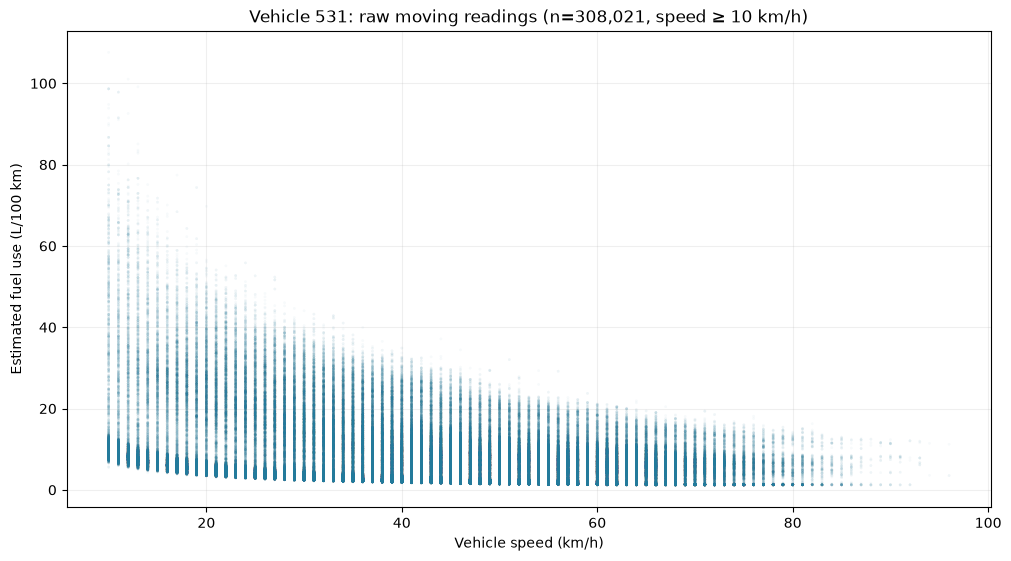

In [16]:
eda = VehicleEDA()
fig, ax = eda.raw_scatter(analysis_df)
fig.savefig(FIGURE_DIR / 'vehicle531_raw_scatter.png', dpi=160, bbox_inches='tight')
plt.show()


### Inspect the data that will be modelled
Raw observations have considerable variation at the same speed. The following scatter shows the 76 prepared speed-level averages, with colour indicating the number of source readings behind each point. It is a descriptive plot, with no fitted line or curve. Averaging reduces visible variability but does not eliminate effects of driving conditions or establish a causal effect of speed.

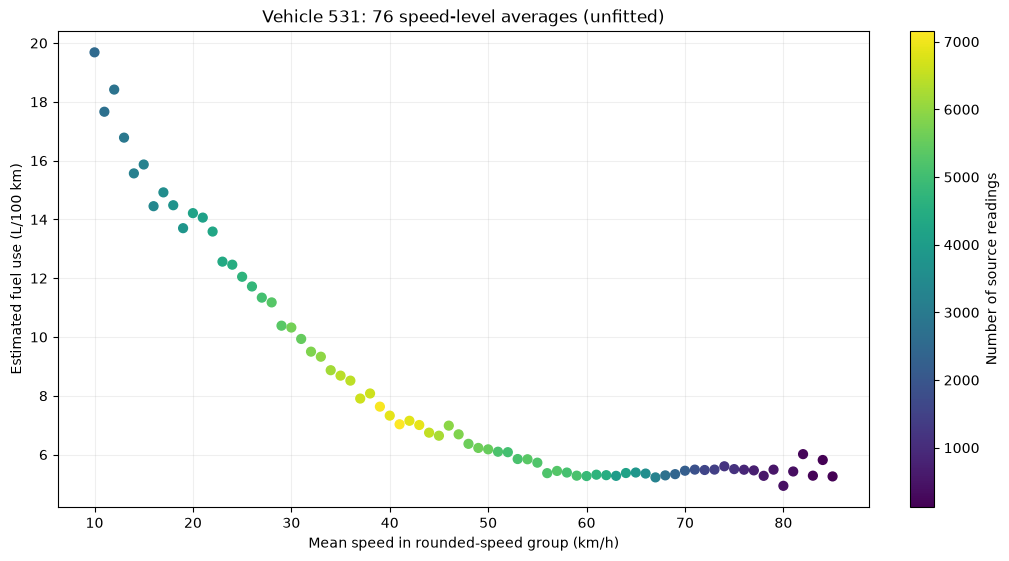

,speed,fuel_use,n_readings
0,10.0,19.684,2516
75,85.0,5.257,117


Lowest observed group average: 4.937 L/100 km at 80 km/h
Raw observations: 308,021; modelling rows: 76


In [17]:
fig, ax = eda.speed_scatter(speed_df)
fig.savefig(FIGURE_DIR / 'vehicle531_speed_averages.png', dpi=160, bbox_inches='tight')
plt.show()
lowest = speed_df.loc[speed_df['fuel_use'].idxmin()]
display(speed_df.iloc[[0, -1]].round(3))
print(f"Lowest observed group average: {lowest['fuel_use']:.3f} L/100 km at {lowest['speed']:.0f} km/h")
print(f"Raw observations: {len(analysis_df):,}; modelling rows: {len(speed_df)}")


### Explain the curvature
The prepared averages fall from about 19.684 L/100 km at 10 km/h to 4.937 L/100 km at 80 km/h, then reach 5.257 L/100 km at 85 km/h. The rate of decrease is not constant: the visible trend motivates a curved candidate rather than assuming a constant slope. The small upturn at the upper end is descriptive; fewer readings support those speeds, so it is not proof of a general optimum.
The target definition helps explain the shape:
$$\mathrm{fuel\_use}=100\,\frac{\mathrm{fuel\_rate}}{\mathrm{speed}}.$$
For a fixed positive fuel rate, this is an inverse curve. For example, 2 L/hr corresponds to 20 L/100 km at 10 km/h and 4 L/100 km at 50 km/h. Actual fuel rate varies too. Since speed is also in the denominator of the target, the association is partly mathematical coupling; this scatter alone cannot identify speed's causal effect.
A quadratic allows changing slope and is the lab's proposed approximation over the observed modelling range of 10–85 km/h. Neither these plots nor the transformation proves that it outperforms a straight line. That question belongs to the later R², RMSE, and residual checks. Results on speed-level averages describe aggregated data and should not be presented as accuracy on individual driving observations.
Preparation limits: MAF-based fuel rate is an estimate under the stated constant-ratio assumptions. The minimum-speed filter changes the study population, and the minimum-count rule removes sparse speed groups. Averaging does not guarantee steady-speed driving or cancel all confounding effects. Each speed average weights every reading equally rather than by elapsed time, so it is not an exact total-fuel/total-distance figure. Part 1 checks that time-weighting gives almost the same curve.

### Create the polynomial feature
Use the shared variable names speed, speed_sq, and fuel_use:

$$\mathrm{fuel\_use}=w_2\,\mathrm{speed\_sq}+w_1\,\mathrm{speed}+b.$$

This expands one predictor into two known features. For example, speed 10 becomes `(10, 100)`, and speed 20 becomes `(20, 400)`. Squared speed has units `(km/h)²`.

The relationship is nonlinear in speed but **linear in the unknown weights**: the weights are neither squared nor multiplied together. The slope `2*w2*speed + w1` can vary with speed, so least squares can represent a bend. The target is unchanged, and no inverse target transformation is required.

In [18]:
before_transform = speed_df.copy(deep=True)
speed_df = PolynomialTransformer().transform(speed_df)
speed = speed_df['speed'].to_numpy()
speed_sq = speed_df['speed_sq'].to_numpy()
fuel_use = speed_df['fuel_use'].to_numpy()

np.testing.assert_array_equal(speed_sq, speed ** 2)
pd.testing.assert_frame_equal(speed_df[before_transform.columns], before_transform)
assert len(speed_df) == 76
assert np.isfinite(speed_df[['speed', 'speed_sq', 'fuel_use']].to_numpy()).all()
display(speed_df[['speed', 'speed_sq', 'fuel_use', 'n_readings']].head(10))
print('Verified: row order, target, counts, and original speed values are unchanged.')


,speed,speed_sq,fuel_use,n_readings
0,10.0,100.0,19.684143,2516
1,11.0,121.0,17.663447,2696
2,12.0,144.0,18.417285,2811
3,13.0,169.0,16.782284,2949
4,14.0,196.0,15.566125,3152
5,15.0,225.0,15.868439,3205
6,16.0,256.0,14.450312,3378
7,17.0,289.0,14.920329,3540
8,18.0,324.0,14.482670,3732
9,19.0,361.0,13.701966,3802


Verified: row order, target, counts, and original speed values are unchanged.


### Note to the modelling team
NumPy: columns [speed_sq, speed, 1] correspond to [w2, w1, b].
scikit-learn: PolynomialFeatures(degree=2, include_bias=False) applied to speed gives [speed, speed_sq]; use w1, w2 = model.coef_ and b = model.intercept_ when the regressor fits an intercept.
Both implementations must use these same 76 rows and the same weighting and any later split. n_readings is descriptive metadata, not an additional predictor. Matching ordinary least squares means each speed-group row has equal weight unless both teams explicitly agree otherwise. The following cell prepares arrays only; it does not fit a model.

In [19]:
X_numpy = np.column_stack([speed_sq, speed, np.ones_like(speed)])
X_sklearn_order = np.column_stack([speed, speed_sq])
x = speed  # Compatibility with the group's existing handoff.
y = fuel_use
assert X_numpy.shape == (76, 3)
assert X_sklearn_order.shape == (76, 2)
FEATURE_PATH = PROJECT_ROOT / 'data' / 'vehicle531_speed_features.csv'
speed_df.to_csv(FEATURE_PATH, index=False)
print('Saved:', FEATURE_PATH.name)
print('NumPy columns: [speed_sq, speed, 1] -> [w2, w1, b]')
print('sklearn columns: [speed, speed_sq] -> [w1, w2], with separate intercept')


Saved: vehicle531_speed_features.csv
NumPy columns: [speed_sq, speed, 1] -> [w2, w1, b]
sklearn columns: [speed, speed_sq] -> [w1, w2], with separate intercept


### Summary

Plotted the retained raw readings and the prepared speed averages, explained why curvature is plausible and what the plots cannot establish, and created speed_sq while preserving the shared modelling rows and target. 

## Part 3: NumPy model (Davis)

Fit fuel use against speed for **vehicle 531** using NumPy ordinary least squares. The quadratic model is

$$\text{fuel\_use} = w_2\,\text{speed}^2 + w_1\,\text{speed} + b.$$

It is polynomial in speed but linear in the unknown weights. The design matrix columns are `[speed², speed, 1]`, so `np.linalg.lstsq` returns `[w₂, w₁, b]` in that order.

### Data

The fit uses the team's shared modelling data: `speed_df` from Part 1, which now includes the `speed_sq` column created in Part 2. Each of the 76 rows is the average fuel use (L/100 km) at one speed from 10 to 85 km/h, built from 308,021 cleaned readings. The cleaning rules (idling removed, speeds below 10 km/h removed, speeds with fewer than 100 readings dropped) are documented in Part 1.

In [20]:
required_columns = {"speed", "speed_sq", "fuel_use"}
missing_columns = required_columns.difference(speed_df.columns)
if missing_columns:
    raise ValueError(f"speed_df is missing required columns: {sorted(missing_columns)}")
if len(speed_df) < 3:
    raise ValueError("At least three observations are needed for a quadratic fit.")

print("Vehicle 531, speed averages from Parts 1 and 2")
print(f"Rows: {len(speed_df)}")
print(f"Speed range: {speed_df['speed'].min():.0f} to {speed_df['speed'].max():.0f} km/h")

Vehicle 531, speed averages from Parts 1 and 2
Rows: 76
Speed range: 10 to 85 km/h


### Build the design matrix and fit

For each observation, one design-matrix row is `[speed², speed, 1]`. Least squares chooses weights that minimize the sum of squared differences between observed and predicted fuel use.

In [21]:
speed = speed_df["speed"].to_numpy(dtype=float)
speed_sq = speed_df["speed_sq"].to_numpy(dtype=float)
fuel_use = speed_df["fuel_use"].to_numpy(dtype=float)

design_matrix = np.column_stack((speed_sq, speed, np.ones_like(speed)))
weights, residual_sum_squares, rank, singular_values = np.linalg.lstsq(
    design_matrix, fuel_use, rcond=None
)
w2, w1, b = weights
fuel_use_pred = design_matrix @ weights

print("Design matrix columns: [speed², speed, 1]")
print(f"Design matrix shape: {design_matrix.shape}")
print(f"Rank: {rank}")
print(f"w₂ = {w2:.8f} L/100km per (km/h)²")
print(f"w₁ = {w1:.8f} L/100km per (km/h)")
print(f"b  = {b:.8f} L/100km")
print(f"Least-squares residual sum of squares: {residual_sum_squares[0]:.8f}")

Design matrix columns: [speed², speed, 1]
Design matrix shape: (76, 3)
Rank: 3
w₂ = 0.00410078 L/100km per (km/h)²
w₁ = -0.54621979 L/100km per (km/h)
b  = 23.13883385 L/100km
Least-squares residual sum of squares: 14.15088685


### Predictions and interpretation

The plot overlays the NumPy predictions on the 76 speed averages used for fitting.

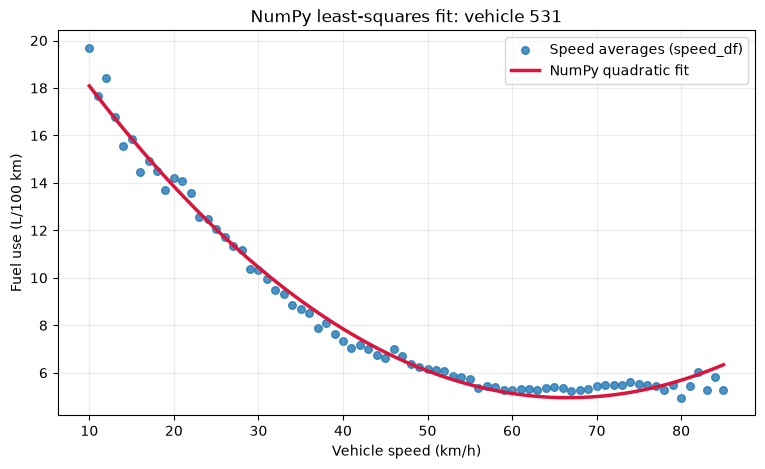

In [22]:
speed_line = np.linspace(speed.min(), speed.max(), 300)
design_line = np.column_stack((speed_line**2, speed_line, np.ones_like(speed_line)))
fuel_use_line = design_line @ weights

plt.figure(figsize=(9, 5))
plt.scatter(speed, fuel_use, s=30, alpha=0.8, label="Speed averages (speed_df)")
plt.plot(speed_line, fuel_use_line, color="crimson", linewidth=2.5, label="NumPy quadratic fit")
plt.xlabel("Vehicle speed (km/h)")
plt.ylabel("Fuel use (L/100 km)")
plt.title("NumPy least-squares fit: vehicle 531")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

### What the weights mean

The weights describe the curve as a whole, so we read them together rather than one at a time:

- **b** is the curve's value at 0 km/h. That is outside the 10–85 km/h data, so it only anchors the curve and has no physical meaning on its own.
- **w₁ < 0**: at low speed, fuel use falls as speed rises.
- **w₂ > 0**: the curve bends upward (a U-shape), so the fall slows down and eventually turns into a rise.
- The slope at any speed is `2·w₂·speed + w₁`. It is zero at `speed = −w₁ / (2·w₂)`, the speed with the lowest predicted fuel use.

In [23]:
best_speed = -w1 / (2 * w2)
best_fuel_use = w2 * best_speed**2 + w1 * best_speed + b

print(f"Lowest predicted fuel use: {best_fuel_use:.2f} L/100km at {best_speed:.1f} km/h")
for s in (20, 50, 80):
    slope = 2 * w2 * s + w1
    print(f"At {s} km/h: predicted {w2 * s**2 + w1 * s + b:.2f} L/100km, slope {slope:+.3f} L/100km per km/h")

Lowest predicted fuel use: 4.95 L/100km at 66.6 km/h
At 20 km/h: predicted 13.85 L/100km, slope -0.382 L/100km per km/h
At 50 km/h: predicted 6.08 L/100km, slope -0.136 L/100km per km/h
At 80 km/h: predicted 5.69 L/100km, slope +0.110 L/100km per km/h


### Handoff to the model-checking section

The fitted coefficients are available as `w2`, `w1`, and `b`; predictions on the 76 speed averages are in `fuel_use_pred`, in the same row order as `speed_df`. The NumPy design-matrix column order is `[speed², speed, 1]`. The model comparison, R²/RMSE metrics, and residual plots belong in Part 4.

The curve is only supported between 10 and 85 km/h. Predictions outside that range are extrapolation (lab §6).

## Part 4: scikit-learn + model checking (Carlos)